# Multimodal (audio-visual) analysis
> This script is running for experiment with auditory and visual (objects) trials.

In [1]:
import datajoint as dj
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches
import itertools
import pandas as pd
import os
from IPython.display import display, HTML
from scipy.stats import sem

# Style of plots
small_size=8
medium_size=20
large_size=40
mpl.rcParams['axes.spines.right'] = False
mpl.rcParams['axes.spines.top'] = False
mpl.rcParams['pdf.fonttype'] =42
mpl.rcParams['axes.grid']=False
mpl.rcParams['axes.titlesize']=small_size
mpl.rcParams["figure.titlesize"] = medium_size
mpl.rcParams['axes.labelsize']=small_size
mpl.rcParams['xtick.labelsize']=small_size
mpl.rcParams['ytick.labelsize']=small_size
mpl.rcParams['legend.fontsize']=small_size


dj.config["enable_python_native_blobs"] = True
dj.config['database.host'] = 'database.eflab.org:3306'
dj.config['database.password'] = os.getenv('DJ_PASSWORD')


schemata = {'exp'   : 'lab_experiments',
            'stim'  : 'lab_stimuli',
            'beh'   : 'lab_behavior',
            'inter' : 'lab_interface',
            'rec'   :'lab_recordings',
            'mice'  : 'lab_mice'}

# create a virtual module for every database schema that you are going to use
for schema, value in schemata.items():
    globals()[schema] = dj.create_virtual_module(schema, value, create_tables=True, create_schema=True)

from multimodal_functions import (
    get_condition_distribution,
    get_scatter_plot_modalities,
    get_visual_performance_summary, 
    plot_visual_performance_per_object,
    get_multimodal_performance_summary, 
    plot_multimodal_performance_per_object,
    get_auditory_performance_summary,
    plot_auditory_performance_per_object,
    get_linePlot_per_modality_across_sessions,
    calculate_response_type,
    # get_multimodal_obj215_trials_summary
    multimodal_obj215
)

[2026-06-24 14:42:33,155][INFO]: DataJoint 0.14.6 connected to eflab@database.eflab.org:3306


In [5]:
# complete the key
animal_id = 299
from_session = 634
to_session = 634

# define the difficulty level
# one difficulty: [2] or multiple difficulties: [1,2,3]
difficulty = [2]

# exclude sessions from plotting
# manual_exclusion_sessions = list(range(180, 280)) + [318,320,322]
manual_exclusion_sessions = []

## Distribution of each condition across sessions

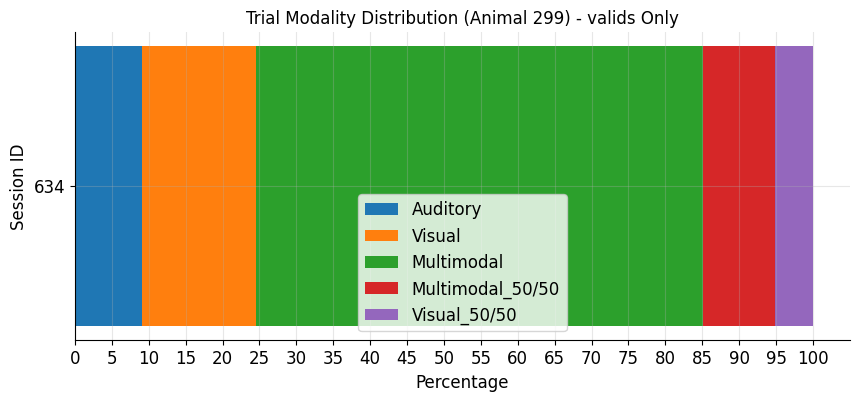

In [3]:
get_condition_distribution(animal_id, from_session, to_session, stim, exp, manual_exclusion_sessions, difficulty, incl_aborts=False)

## Rewards, Punish and Aborts across sessions

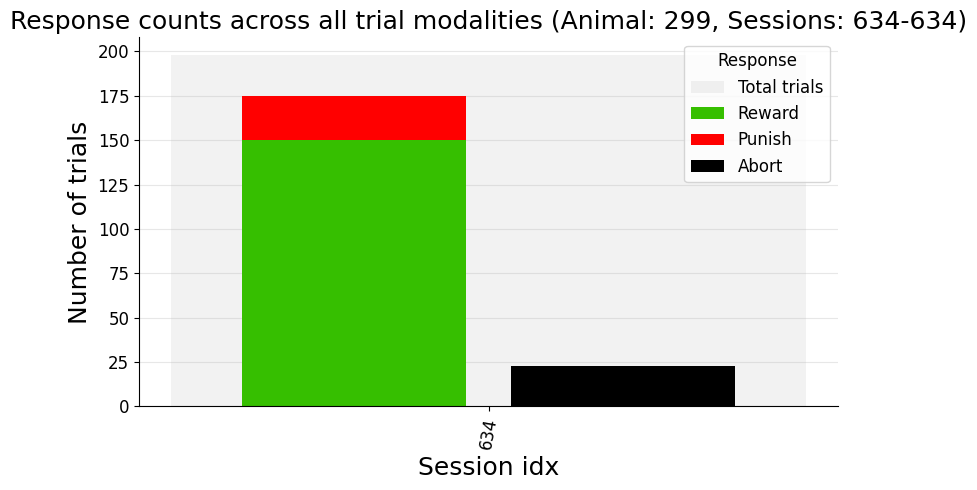

In [4]:
calculate_response_type(animal_id,from_session,to_session,stim,exp,manual_exclusion_sessions,difficulty,)

## Scatter plot beetween modalites across sessions

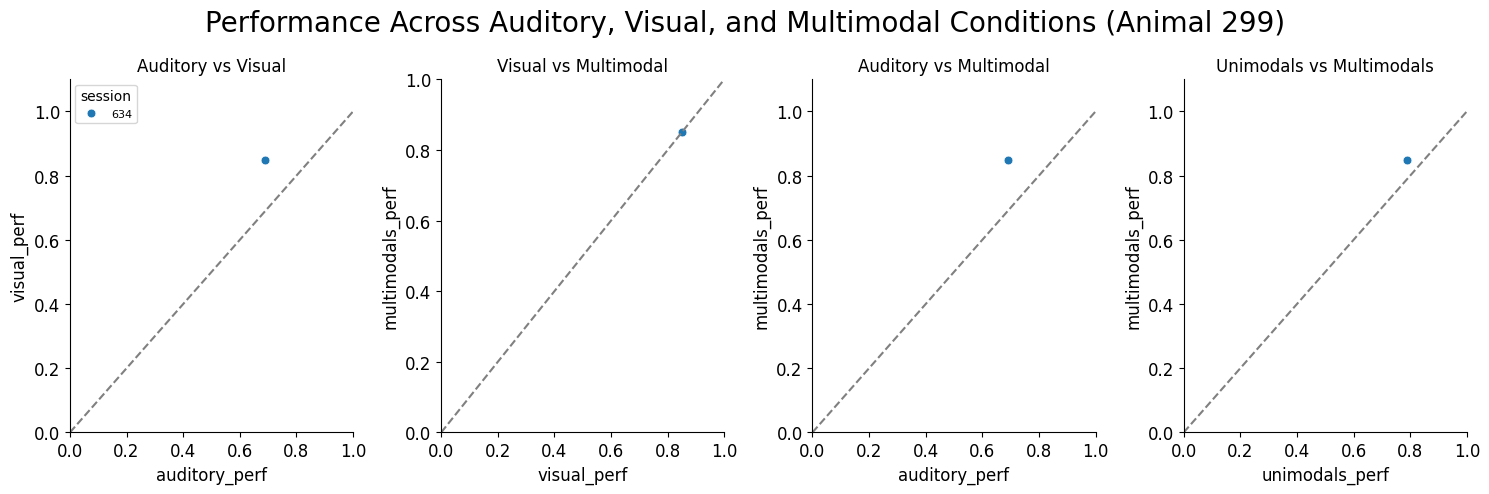

Skipped sessions (missing one or more modalities): []


,session,auditory_perf,visual_perf,multi_perf,uni_perf
0,634,0.69,0.85,0.85,0.79


In [5]:
get_scatter_plot_modalities(animal_id,from_session,to_session,stim, exp,manual_exclusion_sessions,difficulty)

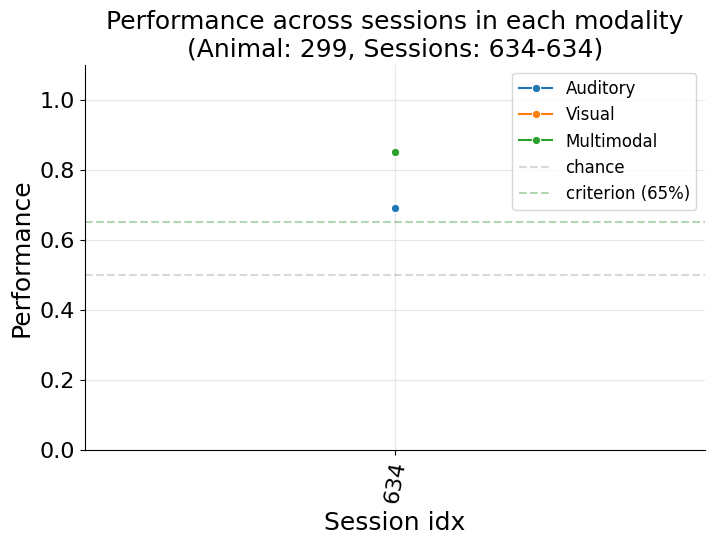

In [6]:
get_linePlot_per_modality_across_sessions(animal_id,from_session,to_session,stim,exp,manual_exclusion_sessions,difficulty,criterion=0.65)

## Performance per object id in each modality across sessions

In [7]:
# Define the key (dict) for unimodal-visual, unimodal-auditory and multimodal trials
# Parameters: animal_id (int), session (int) as a range (from_session, to_session), 
# difficulty level (either one difficulty [1] or multiple [1,2]), object_ids (list), excluded_sessions (list)
# required parameters: animal_id, sessions, difficulties
# defaulted object_ids parameters: [211,212,213,214,215,216,217,218,219]
key = {
    'animal_id': animal_id,
    'sessions': (from_session, to_session), 
    'difficulties': difficulty, 
    'stim': stim,
    'exp': exp,
    'excluded_sessions': manual_exclusion_sessions
}

In [8]:
# Print per-object DataFrames summarizing number of session trials, valid per object trials,
# percentage per object in the session, object performance, rewarded/punished/aborted trials
# Performace in unimodal visual trials:
get_visual_performance_summary(key) 
# Performance in unimodal auditory trials: 
# parameters: key (dict), pulse_freq ('all', '0', '100')
get_auditory_performance_summary(key)
# Performace in multimodal trials:
get_multimodal_performance_summary(key) 

# Line and bar plot of unimodal-visual and multimodal performance across sessions per object. 
# Parameters: key (dict), criterion (float), 
# default criterion: 0.65
# plot_visual_performance_per_object(key)
# plot_auditory_performance_per_object(key)
# plot_multimodal_performance_per_object(key)

Object 212:


,animal_id,session,date,session_trials,valid_obj_trials,performance,reward,punish,abort
0,299,634,2026-06-24,198,7,0.86,6,1,1


Object 213:


,animal_id,session,date,session_trials,valid_obj_trials,performance,reward,punish,abort
0,299,634,2026-06-24,198,6,0.83,5,1,2


Object 215:


...

Object 218:


,animal_id,session,date,session_trials,valid_obj_trials,percentage,performance,reward,punish,abort
0,299,634,2026-06-24,198,29,14.65,0.9,26,3,3


Object 219:


,animal_id,session,date,session_trials,valid_obj_trials,percentage,performance,reward,punish,abort
0,299,634,2026-06-24,198,22,11.11,0.95,21,1,2


{212:    animal_id  session        date  session_trials  valid_obj_trials  \
 0        299      634  2026-06-24             198                18   
 
    percentage  performance  reward  punish  abort  
 0        9.09         0.61      11       7      3  ,
 213:    animal_id  session        date  session_trials  valid_obj_trials  \
 0        299      634  2026-06-24             198                37   
 
    percentage  performance  reward  punish  abort  
 0       18.69         0.86      32       5      5  ,
 215:    animal_id  session        date  session_trials  valid_obj_trials  \
 0        299      634  2026-06-24             198                17   
 
    percentage  performance  reward  punish  abort  
 0        8.59          1.0      17       0      3  ,
 218:    animal_id  session        date  session_trials  valid_obj_trials  \
 0        299      634  2026-06-24             198                29   
 
    percentage  performance  reward  punish  abort  
 0       14.65        

## Analysis of obj. 50-50 trials

In [19]:
get_multimodal_obj215_trials_summary(animal_id,from_session,to_session,stim,exp,manual_exclusion_sessions,difficulty)

,animal_id,session,trial_idx,period,stim_hash,obj_id,time,state,cond_hash,start_time,end_time,obj_mag,difficulty,tone_volume,tone_pulse_freq
0,299,634,8,,Te9cjL1LdXqJnwK3qVW03g==,215,43138,Reward,aPFVcvPWy0szdeWlvXl1Uw==,42481,43106,0.5,2,20,100.0
1,299,634,36,,1CMHYaEofwS8BrlVNUGjtQ==,215,173586,Reward,aPFVcvPWy0szdeWlvXl1Uw==,172887,173585,0.5,2,20,0.0
2,299,634,45,,1CMHYaEofwS8BrlVNUGjtQ==,215,225205,Reward,aPFVcvPWy0szdeWlvXl1Uw==,224481,225205,0.5,2,20,0.0
3,299,634,64,,Te9cjL1LdXqJnwK3qVW03g==,215,290103,Reward,aPFVcvPWy0szdeWlvXl1Uw==,289392,290071,0.5,2,20,100.0
4,299,634,65,,Te9cjL1LdXqJnwK3qVW03g==,215,292672,Reward,aPFVcvPWy0szdeWlvXl1Uw==,292099,292640,0.5,2,20,100.0
5,299,634,76,,1CMHYaEofwS8BrlVNUGjtQ==,215,320893,Reward,aPFVcvPWy0szdeWlvXl1Uw==,320250,320862,0.5,2,20,0.0
6,299,634,109,,1CMHYaEofwS8BrlVNUGjtQ==,215,466967,Reward,aPFVcvPWy0szdeWlvXl1Uw==,466277,466966,0.5,2,20,0.0
7,299,634,128,,1CMHYaEofwS8BrlVNUGjtQ==,215,519189,Reward,aPFVcvPWy0szdeWlvXl1Uw==,518493,519157,0.5,2,20,0.0
8,299,634,130,,Te9cjL1LdXqJnwK3qVW03g==,215,533235,Reward,aPFVcvPWy0szdeWlvXl1Uw==,532275,533201,0.5,2,20,100.0
9,299,634,147,,Te9cjL1LdXqJnwK3qVW03g==,215,581154,Reward,aPFVcvPWy0szdeWlvXl1Uw==,580550,581119,0.5,2,20,100.0


In [8]:
multimodal_obj215.get_trials_summary(self)

NameError: name 'self' is not defined

In [10]:
key = {'animal_id': 299, "session":634}

In [13]:
# first lick per trial
licks = (
    beh.Activity.Lick()
    & key
).fetch(format='frame').reset_index()

first_licks = (
    licks
    .sort_values(['trial_idx', 'time'])
    .drop_duplicates('trial_idx', keep='first')
    [['animal_id', 'session', 'trial_idx', 'port']]
    .rename(columns={
        'port': 'first_lick_port',
    })
)

multi215_trials = (
    stim.StimCondition.Trial 
    * (stim.Panda.Object).proj('obj_mag')  
    * exp.Trial.StateOnset 
    * (stim.Tones).proj('tone_volume', 'tone_pulse_freq') 
    & 'tone_volume > 0'
    & key
    & 'obj_id=215'
    & 'state in ("Reward", "Punish")'
).fetch(format='frame').reset_index()

multi215_trials['obj_mag'] = pd.to_numeric(
    multi215_trials['obj_mag'],
    errors='coerce'
)

multi215_trials = multi215_trials[multi215_trials['obj_mag'] > 0]

# keep only multi215 trials that have a lick
multi215_trials = multi215_trials.merge(
    first_licks,
    on=['animal_id', 'session', 'trial_idx'],
    how='inner'
)

multi215_trials['expected_port'] = np.where(
    multi215_trials['tone_pulse_freq'] == 100,
    2,
    1
)

multi215_trials['followed_tone'] = (
    multi215_trials['first_lick_port']
    == multi215_trials['expected_port']
)

multi215_trials

,animal_id,session,trial_idx,period,stim_hash,obj_id,time,state,start_time,end_time,obj_mag,tone_volume,tone_pulse_freq,first_lick_port,expected_port,followed_tone
0,299,634,8,,Te9cjL1LdXqJnwK3qVW03g==,215,43138,Reward,42481,43106,0.5,20,100.0,2,2,True
1,299,634,36,,1CMHYaEofwS8BrlVNUGjtQ==,215,173586,Reward,172887,173585,0.5,20,0.0,1,1,True
2,299,634,45,,1CMHYaEofwS8BrlVNUGjtQ==,215,225205,Reward,224481,225205,0.5,20,0.0,2,1,False
3,299,634,64,,Te9cjL1LdXqJnwK3qVW03g==,215,290103,Reward,289392,290071,0.5,20,100.0,2,2,True
4,299,634,65,,Te9cjL1LdXqJnwK3qVW03g==,215,292672,Reward,292099,292640,0.5,20,100.0,2,2,True
5,299,634,76,,1CMHYaEofwS8BrlVNUGjtQ==,215,320893,Reward,320250,320862,0.5,20,0.0,2,1,False
6,299,634,109,,1CMHYaEofwS8BrlVNUGjtQ==,215,466967,Reward,466277,466966,0.5,20,0.0,2,1,False
7,299,634,128,,1CMHYaEofwS8BrlVNUGjtQ==,215,519189,Reward,518493,519157,0.5,20,0.0,2,1,False
8,299,634,130,,Te9cjL1LdXqJnwK3qVW03g==,215,533235,Reward,532275,533201,0.5,20,100.0,1,2,False
9,299,634,147,,Te9cjL1LdXqJnwK3qVW03g==,215,581154,Reward,580550,581119,0.5,20,100.0,2,2,True


In [14]:
multi215_perf = round(multi215_trials['followed_tone'].mean(), 2)
print(f"Performance in multimodal trials for object 215: {multi215_perf}")

Performance in multimodal trials for object 215: 0.59


In [15]:
pd.crosstab(
    multi215_trials['tone_pulse_freq'],
    multi215_trials['first_lick_port'],
    normalize='index'
)

first_lick_port,1,2
tone_pulse_freq,,
0.0,0.250000,0.750000
100.0,0.111111,0.888889


(0.0, 1.0)

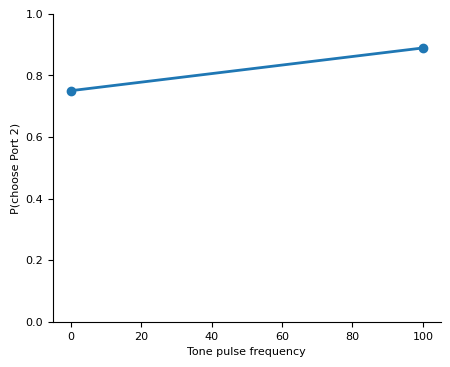

In [16]:
plot_df = (
    multi215_trials
    .assign(
        choose_port2=lambda x: (x['first_lick_port'] == 2).astype(int)
    )
    .groupby('tone_pulse_freq')['choose_port2']
    .mean()
    .reset_index()
)

plt.figure(figsize=(5,4))
plt.plot(
    plot_df['tone_pulse_freq'],
    plot_df['choose_port2'],
    'o-',
    lw=2
)
plt.xlabel('Tone pulse frequency')
plt.ylabel('P(choose Port 2)')
plt.ylim(0,1)

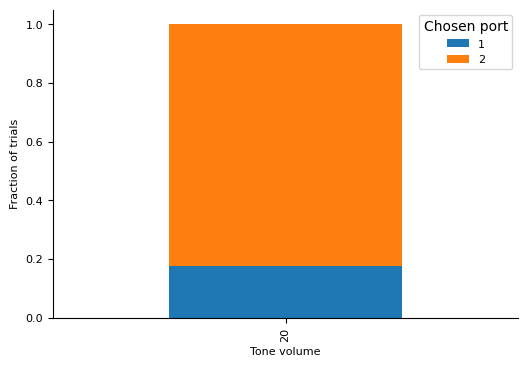

In [17]:
choice_frac = (
    pd.crosstab(
        multi215_trials['tone_volume'],
        multi215_trials['first_lick_port'],
        normalize='index'
    )
)

choice_frac.plot(
    kind='bar',
    stacked=True,
    figsize=(6,4)
)

plt.ylabel('Fraction of trials')
plt.xlabel('Tone volume')
plt.legend(title='Chosen port')

In [18]:
plot_df = (
    multi215_trials
    .assign(
        choose_port2=lambda x:
        (x['first_lick_port']==2).astype(int)
    )
    .groupby('tone_volume')
    .agg(
        p_port2=('choose_port2','mean'),
        n=('choose_port2','size')
    )
    .reset_index()
)